<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
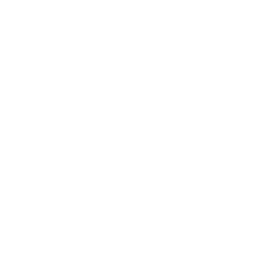
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">평균 분석으로 이상치 학교 식별하기</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 교육 / 성과 분석 &nbsp;|&nbsp; 2026년 3월</p>
</div>
</div>
</div>

## 요약

한 지역 교육 당국은 학군 내 어느 학교가 학군 평균과 진정으로 구별되는
수학 성적을 내는지 알고 싶어 한다 — 단지 순위상 최고와 최저가 아니라,
표집 변동만으로 설명할 수 있는 수준을 초과하는 학교들이다. 평균 분석(ANOM)은
바로 그 질문에 답한다: 각 그룹 평균을 전체 평균과 비교하고 상·하한 결정
한계선을 그어, 평균이 그 밖으로 벗어나는 학교를 표시한다.

이 노트북은 균형 잡힌 8개 학교 코호트(각 12명, 총 96개 레코드)를 구축하고,
`ALPHA=0.05`에서 XCHART로 **PROC ANOM**을 실행하며, 표시된 학교들을 정규성
점검을 위해 **PROC UNIVARIATE**에 입력한다. ANOM은 전체 평균 **499.08**에 대해
**세** 학교를 표시한다: **SCH-02**(평균 532.58)와 **SCH-07**(평균 529.17)은
상한 결정 한계선 **517.93** 위에 있고, **SCH-05**(평균 460.75)는 하한 한계선
**480.23** 아래로 떨어진다. 나머지 다섯 학교는 한계선 안에 머물러 학군
평균과 통계적으로 구별되지 않는다.

## 데이터 출처

| 출처 | 설명 | 레코드 수 |
|--------|-------------|--------:|
| WORK.SCHOOL_SCORES | 학생 수준 수학 시험 점수, 8개 학교 | 96 |

이 코호트는 합성이지만 현실적이다: 각 학교는 학군 목표 500 근처(SD 22)에
중심을 둔 정규 분포에서 점수가 추출되는 12명의 학생을 등록한다. 세 학교에는
의도적인 이동이 부여된다 — 두 곳은 위로, 한 곳은 아래로 — 그래서 분석이
감지할 진짜 신호가 존재한다.

---

In [1]:
/* --------------------------------------------------------
   Generate a balanced 8-school cohort, 12 pupils each (96
   records, within the 100-observation cap). Schools 2 and
   7 are shifted up; school 5 is shifted down, so ANOM has
   real out-of-limit signals to detect.
   -------------------------------------------------------- */
데이터 work.school_scores;
    호출 streaminit(2026);
    반복 school = 1 까지 8;
        school_name = cat('SCH-', PUT(school, z2.));
        shift = 0;
        만약 school = 2 이면 shift = 34;
        만약 school = 5 이면 shift = -38;
        만약 school = 7 이면 shift = 30;
        반복 pupil = 1 까지 12;
            math_score = round(rand('normal', 500 + shift, 22), 1);
            출력;
        종료;
    종료;
    유지 school_name math_score;
실행;

NOTE: DATA work.school_scores


NOTE: Wrote work.school_scores (96 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

### 학교별 기준선

ANOM을 실행하기 전에 각 학교의 수학 점수를 요약한다. 평균은 약 461에서
533까지 걸쳐 있지만, 원시 평균만으로는 어떤 격차가 실제이고 어떤 것이
표집 잡음인지 알 수 없다 — 그것이 바로 다음에 결정 한계선이 판정하는 것이다.

In [2]:
/* --------------------------------------------------------
   Per-school summary of math scores
   -------------------------------------------------------- */
처리 평균 데이터=work.school_scores n mean std MIN MAX maxdec=1;
    분류 school_name;
    변수 math_score;
    제목 'Per-School Math Score Summary';
실행;

                                             Per-School Math Score Summary                                              

                                                  The MEANS Procedure

                                             Analysis Variable : MATH_SCORE

        SCHOOL_NAME          N Obs           Mean        Std Dev        Minimum        Maximum
        --------------------------------------------------------------------------------------
        SCH-01                  12          499.6           26.7          464.0          554.0
        SCH-02                  12          532.6           27.7          491.0          579.0
        SCH-03                  12          485.8           18.1          461.0          513.0
        SCH-04                  12          490.0           23.4          441.0          519.0
        SCH-05                  12          460.8           20.9          441.0          514.0
        SCH-06                  12          497.9           20.8 

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### 평균 분석

PROC ANOM은 각 학교의 평균을 전체 평균과 비교하고 `ALPHA=0.05`에서 상한
(UDL)과 하한(LDL) 결정 한계선을 계산한다. 학교는 그 평균이 한계선을 넘을
때에만 표시된다 — 관리도(control chart)와 동일한 발상이지만, 집단별 오류율을
5%로 유지하면서 그룹 평균들을 동시에 비교하기 위한 것이다. XCHART는 모든
학교 평균을 그 한계선과 대비하여 그린다; 표시된 학교는 강조 표시된다.

                                             Per-School Math Score Summary                                              


                    The ANOM Procedure
                    Analysis of Means for Math Score

  Alpha:            0.0500
  Number of groups: 8
  Grand mean:       499.083333
  MSE:              624.159091

  Group                N       Mean        UDL        LDL     Flag
  -----------------------------------------------------------------
  SCH-01              12   499.5833   517.9339   480.2328         
  SCH-02              12   532.5833   517.9339   480.2328    ABOVE
  SCH-03              12   485.8333   517.9339   480.2328         
  SCH-04              12   490.0000   517.9339   480.2328         
  SCH-05              12   460.7500   517.9339   480.2328    BELOW
  SCH-06              12   497.9167   517.9339   480.2328         
  SCH-07              12   529.1667   517.9339   480.2328    ABOVE
  SCH-08              12   496.8333   517.9339   480.2328         



NOTE: PROC ANOM data=work.school_scores

NOTE: ODS plot written: anom_math_score.spec.json
NOTE: PROC ANOM statement used (96 observations read).
NOTE: ANOM decision limits use Bonferroni-Sidak approximation (conservative). True ANOM uses equicoordinate multivariate t-distribution.


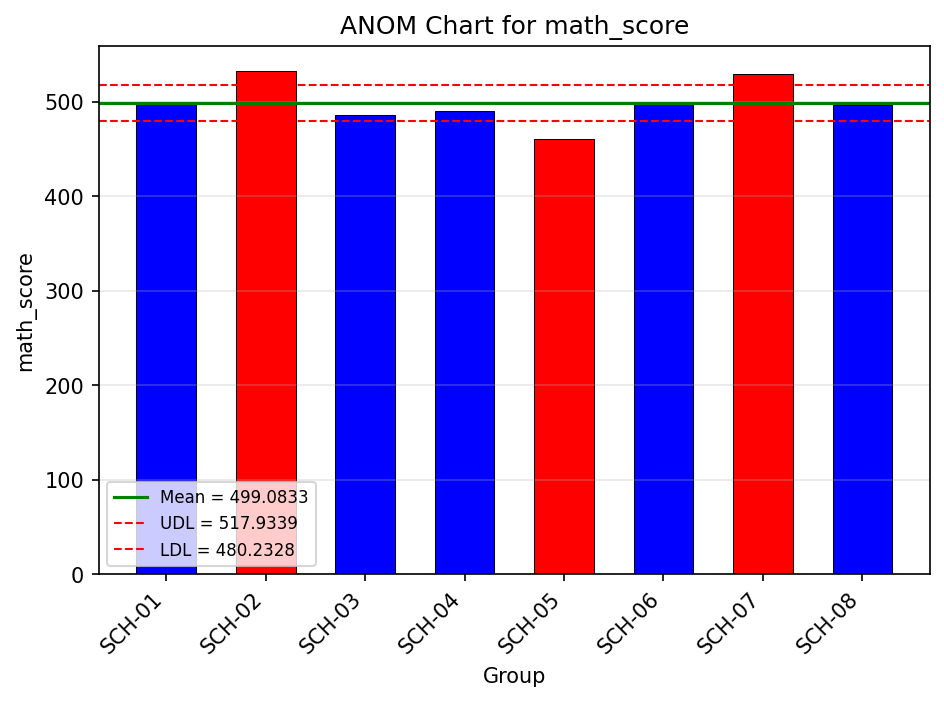

In [3]:
/* --------------------------------------------------------
   PROC ANOM XCHART: test each school mean against the
   grand mean at ALPHA=0.05. OUTTABLE captures the per-school
   means, decision limits, and exceed-limit flags.
   -------------------------------------------------------- */
처리 anom 데이터=work.school_scores;
    xchart math_score * school_name /
        ALPHA=0.05
        outtable=work.anom_table;
    라벨 math_score = 'Math Score'
          school_name = 'School';
    제목 'ANOM: School Math Performance vs District Mean';
실행;

---

### 표시된 학교 포착하기

OUTTABLE 데이터셋은 각 학교당 한 행을 담으며 그 평균(`_SUBX_`), 결정
한계선(`_LDLX_`, `_UDLX_`), 그리고 학교가 한계선을 벗어났을 때 `ABOVE` 또는
`BELOW`로 설정되는 `_EXLIM_` 플래그를 포함한다. 표시된 행을 선택하면 더
자세히 살펴볼 가치가 있는 학교들이 나온다.

In [4]:
/* --------------------------------------------------------
   Keep only schools flagged outside the decision limits
   -------------------------------------------------------- */
데이터 work.outlier_schools;
    설정 work.anom_table;
    조건 _exlim_ ne ' ';
    유지 school_name _subx_ _exlim_;
실행;

처리 인쇄 데이터=work.outlier_schools noobs;
    변수 school_name _subx_ _exlim_;
    제목 'Schools Outside the ANOM Decision Limits';
실행;

                                        Schools Outside the ANOM Decision Limits                                        

SCHOOL_NAME      _SUBX_  _EXLIM_
SCH-02       532.583333  ABOVE
SCH-05           460.75  BELOW
SCH-07       529.166667  ABOVE



NOTE: DATA work.outlier_schools


NOTE: Read 8 rows from work.anom_table.
NOTE: Wrote work.outlier_schools (3 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.outlier_schools

NOTE: PROC PRINT completed: 3 observations printed, 3 variables


---

### 표시된 학교에 대한 진단

ANOM의 결정 한계선은 기저 점수가 근사적으로 정규 분포한다고 가정한다.
플래그에 따라 조치하기 전에, PROC UNIVARIATE의 Shapiro-Wilk 검정으로 표시된
각 학교에서 그 가정을 점검한다.

In [5]:
/* --------------------------------------------------------
   Merge the flagged-school list back to pupil scores and
   run distributional diagnostics on each flagged school.
   -------------------------------------------------------- */
처리 정렬 데이터=work.school_scores; 기준 school_name; 실행;
처리 정렬 데이터=work.outlier_schools; 기준 school_name; 실행;

데이터 work.outlier_scores;
    결합 work.school_scores (IN=a)
          work.outlier_schools (IN=b);
    기준 school_name;
    만약 a 그리고 b;
실행;

처리 단변량 데이터=work.outlier_scores NORMAL;
    분류 school_name;
    변수 math_score;
    HISTOGRAM math_score / NORMAL;
    제목 'Distributional Diagnostics for Flagged Schools';
실행;

                                     Distributional Diagnostics for Flagged Schools                                     

                        SCHOOL_NAME=SCH-02

                                                The UNIVARIATE Procedure
                                                 Variable:  MATH_SCORE

                                                        Moments

N                                 12    Sum Weights                       12
Mean                      532.583333    Sum Observations         6391.000000
Std Deviation              27.655209    Variance                  764.810606
Skewness                    0.074859    Kurtosis                   -0.713041
Uncorrected SS        3412153.000000    Corrected SS             8412.916667
Coeff Variation             5.192654    Std Error Mean              7.983371

          Basic Statistical Measures           

Location              Variability              
--------  ----------  -------------  ----------
Mean      532.58

NOTE: PROC SORT data=work.school_scores

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 96 rows from work.school_scores.
NOTE: Wrote work.school_scores (96 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.outlier_schools

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 3 rows from work.outlier_schools.
NOTE: Wrote work.outlier_schools (3 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.outlier_scores

NOTE: Stream 1 processed 96 rows, max BY-group size: 12 (O(1) memory verified)
NOTE: Stream 2 processed 3 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.outlier_scores (36 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC UNIVARIATE


---

### 해석

ANOM XCHART는 전체 평균 **499.08**(UDL **517.93**, LDL **480.23**)에 대해
여덟 학교 중 **세** 곳을 표시한다:

- **SCH-02** — 평균 **532.58**, 상한 결정 한계선 위.
- **SCH-07** — 평균 **529.17**, 상한 결정 한계선 위.
- **SCH-05** — 평균 **460.75**, 하한 결정 한계선 아래.

다른 다섯 학교(SCH-01, SCH-03, SCH-04, SCH-06, SCH-08)는 한계선 안에 든다;
학군 평균과의 차이는 표집 변동만으로 생길 수 있는 범위 내에 있으므로 조치가
필요하지 않다.

PROC UNIVARIATE 정규성 점검은 플래그를 한정한다. 두 상위 성과 학교는 깔끔하게
정규적이며 — SCH-02(Shapiro-Wilk W **0.966**, p **0.860**)와 SCH-07(W **0.967**,
p **0.883**) — 따라서 그들의 높은 평균은 신뢰할 만한 신호이다. 그러나 하위
성과 학교 **SCH-05**는 정규성 검정에 실패한다(W **0.803**, p **0.010**, 왜도
**1.76**): 그 분포는 오른쪽으로 치우쳐 있으며, 대부분의 학생은 낮지만 몇몇은
학군 표준 근처에 있다. 이것은 유용한 단서이다 — SCH-05의 부진은 실제이지만,
균일한 이동이 아니라 어려움을 겪는 학생들의 집중된 집단에 의해 유발되며, 이는
전교 프로그램보다는 표적 개입을 가리킨다.

ANOM은 단순 순위가 할 수 없는 것을 제공한다: 학군 평균과 진정으로 다른 세
학교를 그렇게 보이기만 하는 다섯 학교와 분리하며, 학군 지도부가 한눈에 읽을
수 있는 단일 차트로 그렇게 한다.

---

In [6]:
/* --------------------------------------------------------
   Export the per-school ANOM results (means, decision
   limits, and flags) for district leadership.
   -------------------------------------------------------- */
처리 EXPORT 데이터=work.anom_table
    OUTFILE='school_anom_results.csv'
    DBMS=csv REPLACE;
실행;

NOTE: PROC EXPORT data=work.anom_table outfile=school_anom_results.csv

NOTE: Exported 8 rows to school_anom_results.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 기밀
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Jenner 제공: <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>